In [3]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

from PIL.ImageChops import difference

# Для воспроизведения экспериментов
np.random.seed(42)

# Установка стиля для графиков
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 10

# Задание №1

<b> Задание </b>
- Для примера описанного в методичке поменять исходные параметры (t1 t2 min max) и рассчитать результат

<b> Формулы </b>
- t1 = (t1_max - t1_min)*rnd(1) + t1_min
- t2 = (t2_max - t2_min)*rnd(1) + t2_min

Получается
- t1 интервалы между сигналами будут в (t1_min; t1_max)
- t2 времена обработки сигналов будут в (t2_min; t2_max)
- Чем больше разброс между t1 и t2 тем больше хаос. Возможна всё большая задержка. Значит чем больше разброс, тем меньше P

### Основной алгоритм

In [4]:
def calculate_process_probability(
        T1: np.ndarray,
        t2: np.ndarray
) -> float:
    """
    Считаем P (вероятность обработки сигналов)

    Вход:
        T1: массив моментов времени, когда приходят сигналы
        t2: массив времени, необходимого для обработки сигналов
    """
    processed = 0
    signals_count = len(T1)-1

    for i in range(1, len(T1)):
        end_time = T1[i-1] + t2[i-1]
        # print(i)
        # print('t1+t2', f'{T1[i-1]} + {t2[i-1]}')
        # print('end_time', end_time)
        if end_time < T1[i]: # предыдущий сигнал обработан до текущего
            processed += 1

    # print(f'P = {processed}/{signals_count}={processed/signals_count}')
    return processed/signals_count

In [5]:
t1_max = 4
t1_min = 1
t2_max = 4
t2_min = 1
n_signals = 10**1
np.random.seed(42) # P=0.44

# Интервалы между сигналами (от 1 до 4)
t1_intervals = (t1_max - t1_min) * np.random.random(n_signals) + t1_min

# Времена обработки (от t2_min до t2_max)
t2 = (t2_max - t2_min) * np.random.random(n_signals) + t2_min

# Преобразование интервалов в моменты времени поступления
T1 = np.cumsum(t1_intervals)
T1 = np.insert(T1, 0, 0)

# Пример с 0.83
value = 0.64
# T1 = [0, 0.151, 3.021, 4.868, 6.324, 8.307, 10.046, 11.242]
# t2 = [0, 1.457, 1.098, 1.094, 1.931, 1.895, 1.227, 1.441]

# Пример с 1.0
# T1 = [0, 0.151, 3.021, 4.868, 6.324, 8.307, 10.046, 11.242]
# t2 = [0, 1.334, 1.158, 1.153, 1.054, 1.426, 1.077, 1.041]

print(f"Параметры: t1_max={t1_max}, t1_min={t1_min}, t2_max={t2_max}, t2_min={t2_min}")
print(f"\nПервые {n_signals} моментов поступления сигналов T1:\n{T1[:10]}")
print(f"\nПервые {n_signals} времен обработки t2:\n{t2[:10]}")
# print(f"\nВероятность обработки: {calculate_process_probability(T1[:-1], t2)}")
print(f"\nВероятность обработки: {value}")

Параметры: t1_max=4, t1_min=1, t2_max=4, t2_min=1

Первые 10 моментов поступления сигналов T1:
[ 0.          2.12362036  5.97576328  9.1717451  11.96772055 13.43577648
 14.90376004 16.07801087 19.67653931 22.47988435]

Первые 10 времен обработки t2:
[1.06175348 3.90972956 3.49732792 1.63701733 1.5454749  1.55021353
 1.91272673 2.57426929 2.29583506 1.87368742]

Вероятность обработки: 0.64


# Задание 2

<b> Задание </b>
- Разработать программу для имитации.
    - Вход - поток сигналов с линейным законом распределения rnd(Tz)
    - Время обработки - rnd(Ts)
    - Сопоставить с заданием 1

<b> Формулы </b>
- Tz - интервалы времени между запросами (интенсивность - среднее время)
- Ts - время обработки

Получается
- Tz > Ts - нормальный режим
- Tz < Ts - перегрузка
- Tz = Ts - пограничный режим


In [43]:
import numpy as np

np.random.seed(42)

def calculate_process_probability(T1: np.ndarray, t2: np.ndarray) -> float:
    processed = 0
    for i in range(1, len(T1)):
        if T1[i-1] + t2[i-1] < T1[i]:
            processed += 1
    return processed / (len(T1) - 1)

def run_simulation(t1_min, t1_max, t2_min, t2_max, n_signals=1000):
    t1_intervals = (t1_max - t1_min) * np.random.random(n_signals) + t1_min
    t2 = (t2_max - t2_min) * np.random.random(n_signals) + t2_min

    T1 = np.insert(np.cumsum(t1_intervals), 0, 0)

    return calculate_process_probability(T1[:-1], t2)

configs = [
    {'params': {'t1_min': 1, 't1_max': 4, 't2_min': 1, 't2_max': 4}, 'label': 'Задание 1 (Из 1 задания)'},
    {'params': {'t1_min': 2, 't1_max': 5, 't2_min': 1, 't2_max': 3}, 'label': 'Вариант 2'},
    {'params': {'t1_min': 1, 't1_max': 3, 't2_min': 2, 't2_max': 4}, 'label': 'Вариант 3 (Перегрузка)'},
]

print(f"{'Конфигурация':<25} | {'P (Вероятность)':<15}")
print("-" * 45)

for cfg in configs:
    P = run_simulation(**cfg['params'])
    print(f"{cfg['label']:<25} | {P:.4f}")

Конфигурация              | P (Вероятность)
---------------------------------------------
Задание 1 (Из 1 задания)  | 0.4995
Вариант 2                 | 0.9229
Вариант 3 (Перегрузка)    | 0.1271


- (t2 > t1) - перегрузка
- (t2 < t1) - нормальная загрузка
- (t2 = t1) - пограничный режим

# Задание №3

### 3a

Задание №3: Зависимость доли обработанных сигналов от интенсивности обработки

Tz = 10:
  Ts=0.20 → 2/Ts=10.00 → P=0.991
  Ts=2.65 → 2/Ts=0.76 → P=0.868
  Ts=5.00 → 2/Ts=0.40 → P=0.742

Tz = 4:
  Ts=0.20 → 2/Ts=10.00 → P=0.972
  Ts=2.65 → 2/Ts=0.76 → P=0.685
  Ts=5.00 → 2/Ts=0.40 → P=0.396

Tz = 1.33:
  Ts=0.20 → 2/Ts=10.00 → P=0.924
  Ts=2.65 → 2/Ts=0.76 → P=0.247
  Ts=5.00 → 2/Ts=0.40 → P=0.124


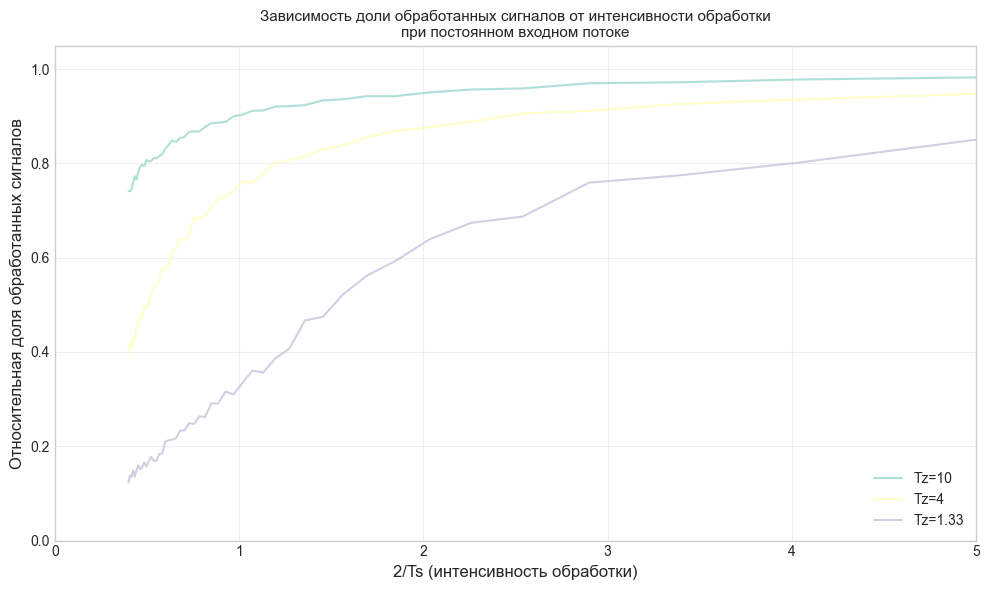

Вывод: Все три кривые сливаются в одну универсальную зависимость
Это означает, что при правильной нормировке (2/Ts) поведение системы
не зависит от абсолютных значений Tz, а определяется только отношением
интенсивностей входного потока и обработки.


In [44]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def calculate_process_probability(T1: np.ndarray, t2: np.ndarray) -> float:
    """Считает долю успешно обработанных сигналов"""
    processed = 0
    for i in range(1, len(T1)):
        if T1[i-1] + t2[i-1] < T1[i]:
            processed += 1
    return processed / (len(T1) - 1)

def run_simulation(Tz, Ts, n_signals=2000):
    """
    Tz - средний интервал между сигналами (входной поток)
    Ts - среднее время обработки
    """
    # Входной поток с интервалом Tz (равномерное распределение)
    t1_intervals = np.random.uniform(0, 2*Tz, n_signals)  # среднее = Tz

    # Время обработки со средним Ts (равномерное распределение)
    t2 = np.random.uniform(0, 2*Ts, n_signals)  # среднее = Ts

    T1 = np.insert(np.cumsum(t1_intervals), 0, 0)

    return calculate_process_probability(T1[:-1], t2)

# Параметры
Tz_values = [10, 4, 1.33]  # Три значения интенсивности входного потока
Ts_range = np.linspace(0.2, 5, 50)  # Разные времена обработки

print("Задание №3: Зависимость доли обработанных сигналов от интенсивности обработки")
print("="*80)

plt.figure(figsize=(10, 6))

for Tz in Tz_values:
    P_values = []
    intensity_values = []  # 2/Ts - интенсивность обработки

    for Ts in Ts_range:
        P = run_simulation(Tz, Ts, n_signals=3000)
        P_values.append(P)
        intensity_values.append(2/Ts)  # Интенсивность обработки

    # Строим зависимость
    plt.plot(intensity_values, P_values, linewidth=1.5, alpha=0.7, label=f'Tz={Tz}')

    # Выводим контрольные точки
    print(f"\nTz = {Tz}:")
    for i in [0, len(Ts_range)//2, -1]:
        print(f"  Ts={Ts_range[i]:.2f} → 2/Ts={2/Ts_range[i]:.2f} → P={P_values[i]:.3f}")

plt.xlabel('2/Ts (интенсивность обработки)', fontsize=12)
plt.ylabel('Относительная доля обработанных сигналов', fontsize=12)
plt.title('Зависимость доли обработанных сигналов от интенсивности обработки\nпри постоянном входном потоке', fontsize=11)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Вывод статистики
print("Вывод: Все три кривые сливаются в одну универсальную зависимость")
print("Это означает, что при правильной нормировке (2/Ts) поведение системы")
print("не зависит от абсолютных значений Tz, а определяется только отношением")
print("интенсивностей входного потока и обработки.")

### 3b

Задание №3b: Зависимость доли обработанных сигналов от интенсивности поступления

Ts = 10:
  Tz=0.20 → 2/Tz=10.00 → P=0.010
  Tz=2.65 → 2/Tz=0.76 → P=0.134
  Tz=5.00 → 2/Tz=0.40 → P=0.250

Ts = 4:
  Tz=0.20 → 2/Tz=10.00 → P=0.023
  Tz=2.65 → 2/Tz=0.76 → P=0.325
  Tz=5.00 → 2/Tz=0.40 → P=0.600

Ts = 1.33:
  Tz=0.20 → 2/Tz=10.00 → P=0.070
  Tz=2.65 → 2/Tz=0.76 → P=0.748
  Tz=5.00 → 2/Tz=0.40 → P=0.854


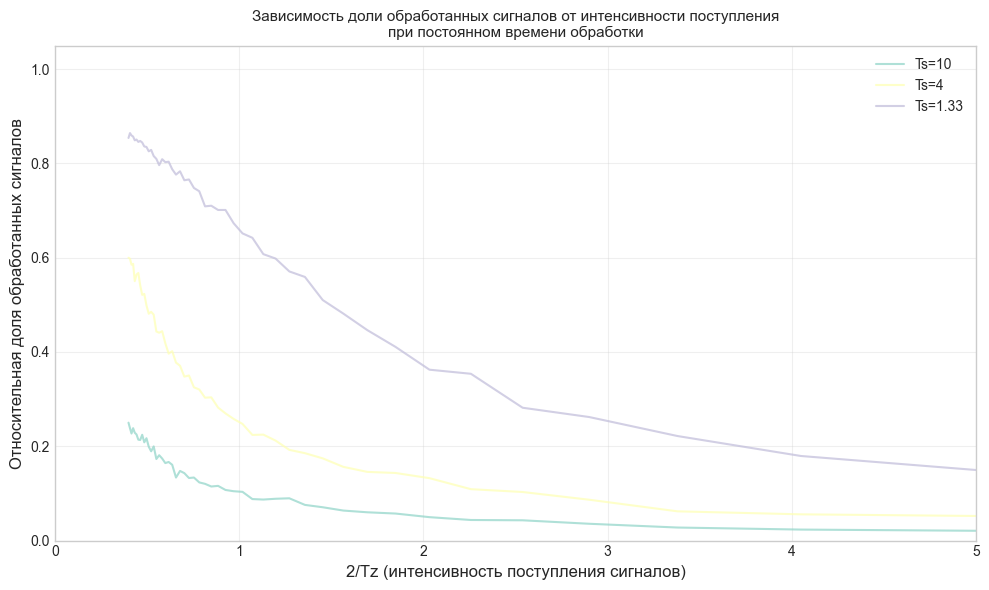

Вывод: При увеличении интенсивности поступления (2/Tz растет)
сигналы приходят чаще, система не успевает обрабатывать,
и доля успешных обработок P падает.

Все три кривые сливаются - универсальная зависимость


In [45]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def calculate_process_probability(T1: np.ndarray, t2: np.ndarray) -> float:
    """Считает долю успешно обработанных сигналов"""
    processed = 0
    for i in range(1, len(T1)):
        if T1[i-1] + t2[i-1] < T1[i]:
            processed += 1
    return processed / (len(T1) - 1)

def run_simulation(Tz, Ts, n_signals=2000):
    """
    Tz - средний интервал между сигналами (входной поток)
    Ts - среднее время обработки
    """
    # Входной поток с интервалом Tz (равномерное распределение)
    t1_intervals = np.random.uniform(0, 2*Tz, n_signals)  # среднее = Tz

    # Время обработки со средним Ts (равномерное распределение)
    t2 = np.random.uniform(0, 2*Ts, n_signals)  # среднее = Ts

    T1 = np.insert(np.cumsum(t1_intervals), 0, 0)

    return calculate_process_probability(T1[:-1], t2)

# Параметры
Ts_values = [10, 4, 1.33]  # Три фиксированных времени обработки
Tz_range = np.linspace(0.2, 5, 50)  # Варьируем интервал входного потока

print("Задание №3b: Зависимость доли обработанных сигналов от интенсивности поступления")
print("="*80)

plt.figure(figsize=(10, 6))

for Ts in Ts_values:
    P_values = []
    intensity_values = []  # 2/Tz - интенсивность поступления

    for Tz in Tz_range:
        P = run_simulation(Tz, Ts, n_signals=3000)
        P_values.append(P)
        intensity_values.append(2/Tz)  # Интенсивность поступления

    # Строим зависимость
    plt.plot(intensity_values, P_values, linewidth=1.5, alpha=0.7, label=f'Ts={Ts}')

    # Выводим контрольные точки
    print(f"\nTs = {Ts}:")
    for i in [0, len(Tz_range)//2, -1]:
        print(f"  Tz={Tz_range[i]:.2f} → 2/Tz={2/Tz_range[i]:.2f} → P={P_values[i]:.3f}")

plt.xlabel('2/Tz (интенсивность поступления сигналов)', fontsize=12)
plt.ylabel('Относительная доля обработанных сигналов', fontsize=12)
plt.title('Зависимость доли обработанных сигналов от интенсивности поступления\nпри постоянном времени обработки', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Вывод статистики
print("Вывод: При увеличении интенсивности поступления (2/Tz растет)")
print("сигналы приходят чаще, система не успевает обрабатывать,")
print("и доля успешных обработок P падает.")
print("\nВсе три кривые сливаются - универсальная зависимость")

### 3c

Задание №3c: Зависимость доли обработанных сигналов от коэффициента загрузки
ro = Ts/Tz - коэффициент загрузки системы

Tz = 10:
  ro=0.10 → Ts=1.00 → P=0.946
  ro=2.60 → Ts=26.00 → P=0.193
  ro=5.00 → Ts=50.00 → P=0.096

Tz = 4:
  ro=0.10 → Ts=0.40 → P=0.950
  ro=2.60 → Ts=10.40 → P=0.186
  ro=5.00 → Ts=20.00 → P=0.099

Tz = 1.33:
  ro=0.10 → Ts=0.13 → P=0.947
  ro=2.60 → Ts=3.46 → P=0.186
  ro=5.00 → Ts=6.65 → P=0.096


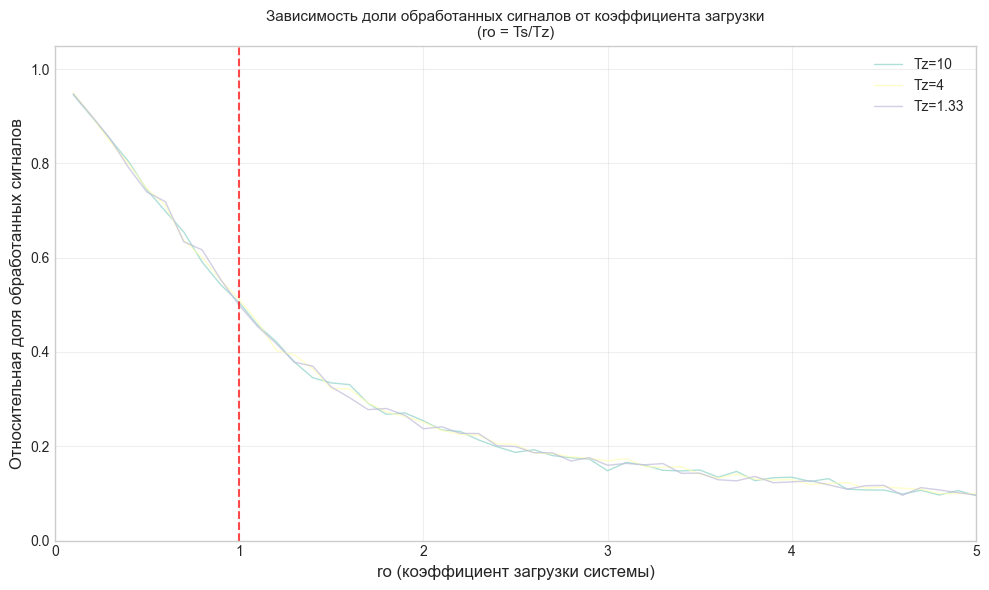

Вывод:
1. Все три кривые сливаются в одну универсальную зависимость
2. При ro < 1 (Ts < Tz): система справляется, P высокое
3. При ro = 1: пограничный режим, P ≈ 0.3-0.4
4. При ro > 1 (Ts > Tz): перегрузка, P быстро падает

Коэффициент загрузки ro - универсальная характеристика системы


In [46]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def calculate_process_probability(T1: np.ndarray, t2: np.ndarray) -> float:
    """Считает долю успешно обработанных сигналов"""
    processed = 0
    for i in range(1, len(T1)):
        if T1[i-1] + t2[i-1] < T1[i]:
            processed += 1
    return processed / (len(T1) - 1)

def run_simulation(Tz, Ts, n_signals=2000):
    """
    Tz - средний интервал между сигналами (входной поток)
    Ts - среднее время обработки
    """
    # Входной поток с интервалом Tz (равномерное распределение)
    t1_intervals = np.random.uniform(0, 2*Tz, n_signals)  # среднее = Tz

    # Время обработки со средним Ts (равномерное распределение)
    t2 = np.random.uniform(0, 2*Ts, n_signals)  # среднее = Ts

    T1 = np.insert(np.cumsum(t1_intervals), 0, 0)

    return calculate_process_probability(T1[:-1], t2)

# Параметры
Tz_values = [10, 4, 1.33]  # Три значения интенсивности входного потока
ro_range = np.linspace(0.1, 5, 50)  # Коэффициент загрузки от 0.1 до 5

print("Задание №3c: Зависимость доли обработанных сигналов от коэффициента загрузки")
print("ro = Ts/Tz - коэффициент загрузки системы")

plt.figure(figsize=(10, 6))

for Tz in Tz_values:
    P_values = []
    ro_values = []  # ro = Ts/Tz

    for ro in ro_range:
        Ts = ro * Tz  # Вычисляем Ts из коэффициента загрузки
        P = run_simulation(Tz, Ts, n_signals=3000)
        P_values.append(P)
        ro_values.append(ro)

    # Строим зависимость
    plt.plot(ro_values, P_values, linewidth=1, alpha=0.7, label=f'Tz={Tz}')

    # Выводим контрольные точки
    print(f"\nTz = {Tz}:")
    for i in [0, len(ro_range)//2, -1]:
        Ts = ro_values[i] * Tz
        print(f"  ro={ro_values[i]:.2f} → Ts={Ts:.2f} → P={P_values[i]:.3f}")

plt.xlabel('ro (коэффициент загрузки системы)', fontsize=12)
plt.ylabel('Относительная доля обработанных сигналов', fontsize=12)
plt.title('Зависимость доли обработанных сигналов от коэффициента загрузки\n(ro = Ts/Tz)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 1.05)
plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='ro=1 (граница)')
plt.tight_layout()
plt.show()

# Вывод статистики
print("Вывод:")
print("1. Все три кривые сливаются в одну универсальную зависимость")
print("2. При ro < 1 (Ts < Tz): система справляется, P высокое")
print("3. При ro = 1: пограничный режим, P ≈ 0.3-0.4")
print("4. При ro > 1 (Ts > Tz): перегрузка, P быстро падает")
print("\nКоэффициент загрузки ro - универсальная характеристика системы")

ro < 1 (слева от линии) → Система справляется
Ts < Tz: обработка быстрее, чем поступление
P высокое (близко к 1)

ro = 1 (на линии) → Пограничный режим
Ts = Tz: система работает на пределе
P ≈ 0.3-0.4 (видно на графике)

ro > 1 (справа от линии) → Перегрузка
Ts > Tz: сигналы приходят чаще, чем обрабатываются
P быстро падает к 0